<a href="https://colab.research.google.com/github/purposemail117-code/smart-finance-dashboard/blob/main/smart_finance.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving Personal_Finance_Dashboard_Resume_Quality_500Rows.csv to Personal_Finance_Dashboard_Resume_Quality_500Rows.csv


In [ ]:
import pandas as pd

df = pd.read_csv('Personal_Finance_Dashboard_Resume_Quality_500Rows.csv')
df.head()

,Transaction_ID,Date,Month,Year,Category,Subcategory,Type,Amount,Payment_Method,Merchant,City,Account_Type,Savings_Goal
0,TXN1031,2025-01-01,January,2025,Entertainment,Entertainment,Expense,2084,Credit Card,Netflix,Chennai,HDFC Savings,Investments
1,TXN1037,2025-01-01,January,2025,Food,Food,Expense,310,Debit Card,Zomato,Bengaluru,SBI Savings,Emergency Fund
2,TXN1002,2025-01-02,January,2025,Income,Freelance,Income,14455,Bank Transfer,Additional Income,Hyderabad,SBI Savings,Emergency Fund
3,TXN1039,2025-01-02,January,2025,Healthcare,Healthcare,Expense,3876,Net Banking,MedPlus,Bengaluru,SBI Savings,Emergency Fund
4,TXN1004,2025-01-02,January,2025,Income,Freelance,Income,8104,Bank Transfer,Additional Income,Hyderabad,SBI Savings,Travel Fund


In [ ]:
df.info()
df.shape


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 492 entries, 0 to 491
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Transaction_ID  492 non-null    object
 1   Date            492 non-null    object
 2   Month           492 non-null    object
 3   Year            492 non-null    int64 
 4   Category        492 non-null    object
 5   Subcategory     492 non-null    object
 6   Type            492 non-null    object
 7   Amount          492 non-null    int64 
 8   Payment_Method  492 non-null    object
 9   Merchant        492 non-null    object
 10  City            492 non-null    object
 11  Account_Type    492 non-null    object
 12  Savings_Goal    492 non-null    object
dtypes: int64(2), object(11)
memory usage: 50.1+ KB


(492, 13)

In [ ]:
df['Date'] = pd.to_datetime(df['Date'])
print(df['Date'].head())

0   2025-01-01
1   2025-01-01
2   2025-01-02
3   2025-01-02
4   2025-01-02
Name: Date, dtype: datetime64[ns]


In [ ]:
df.isnull().sum()

,0
Transaction_ID,0
Date,0
Month,0
Year,0
Category,0
Subcategory,0
Type,0
Amount,0
Payment_Method,0
Merchant,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.head()
df.describe()


,Date,Year,Amount
count,492,492.0,492.000000
mean,2025-06-27 19:07:19.024390144,2025.0,4247.689024
min,2025-01-01 00:00:00,2025.0,54.000000
25%,2025-03-26 12:00:00,2025.0,734.750000
50%,2025-06-27 12:00:00,2025.0,1967.500000
75%,2025-09-27 06:00:00,2025.0,4287.500000
max,2025-12-28 00:00:00,2025.0,64399.000000
std,NaN,0.0,8825.219103


In [ ]:
df['Category'].value_counts()

,count
Category,
Food,62
Healthcare,58
Transport,57
Utilities,51
Travel,50
Education,47
Shopping,43
Entertainment,41
Insurance,38


In [ ]:
df['Type'].value_counts()

,count
Type,
Expense,459
Income,33


In [ ]:
total_income = df[df['Type']=='Income']['Amount'].sum()

print(total_income)

850302


In [ ]:
total_expense = df[df['Type']=='Expense']['Amount'].sum()

print(total_expense)

1239561


In [ ]:
net_savings = total_income - total_expense

print(net_savings)

-389259


In [ ]:
savings_rate = (net_savings/total_income)*100

print(round(savings_rate,2))

-45.78


In [ ]:
monthly_income = (
    df[df['Type']=='Income']
    .groupby('Month')['Amount']
    .sum()
)
monthly_income

,Amount
Month,
April,76996
August,66339
December,58598
February,75196
January,77452
July,52179
June,74582
March,66950
May,70820


In [ ]:
month_order = [
    'January', 'February', 'March', 'April',
    'May', 'June', 'July', 'August',
    'September', 'October', 'November', 'December'
]

monthly_expense = (
    df[df['Type']=='Expense']
    .groupby('Month')['Amount']
    .sum()
    .reindex(month_order)
)

print(monthly_expense)

Month
January      135726
February     124635
March        110474
April         89739
May           84037
June         119342
July          99895
August       100387
September    100781
October       88086
November      94893
December      91566
Name: Amount, dtype: int64


In [ ]:

monthly_summary = pd.pivot_table(
    df,
    values='Amount',
    index='Month',
    columns='Type',
    aggfunc='sum'
)

monthly_summary

Type,Expense,Income
Month,,
April,89739,76996
August,100387,66339
December,91566,58598
February,124635,75196
January,135726,77452
July,99895,52179
June,119342,74582
March,110474,66950
May,84037,70820


In [ ]:
category_expense = (
    df[df['Type']=='Expense']
    .groupby('Category')['Amount']
    .sum()
    .sort_values(ascending=False)
)

category_expense

,Amount
Category,
Travel,308651
Education,164356
Insurance,163976
Housing,153498
Shopping,140196
Healthcare,100384
Utilities,85605
Entertainment,61227
Food,39157


In [ ]:
top_merchants = (
    df.groupby('Merchant')['Amount']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_merchants

,Amount
Merchant,
Employer Payroll,675312
IRCTC,195638
Additional Income,174990
House Rent,153498
MakeMyTrip,113013
LIC,87718
Coursera,83380
HDFC Ergo,76258
MedPlus,66621


In [ ]:
payment_analysis = (
    df.groupby('Payment_Method')['Amount']
    .sum()
    .sort_values(ascending=False)
)

payment_analysis

,Amount
Payment_Method,
Bank Transfer,850302
Net Banking,362725
UPI,307667
Debit Card,306799
Credit Card,262370


<Axes: xlabel='Month'>

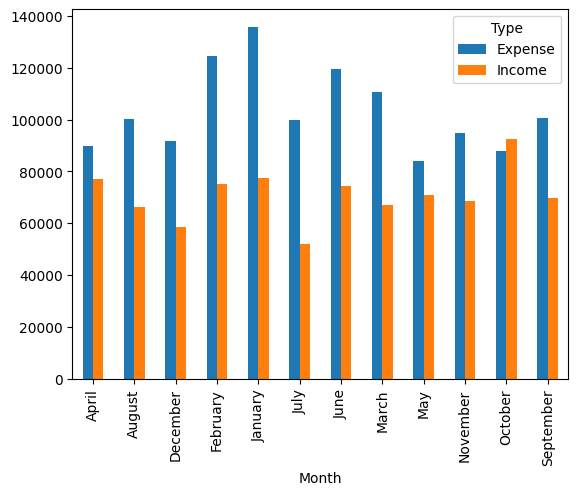

In [ ]:
monthly_summary.plot(kind='bar')

<Axes: xlabel='Category'>

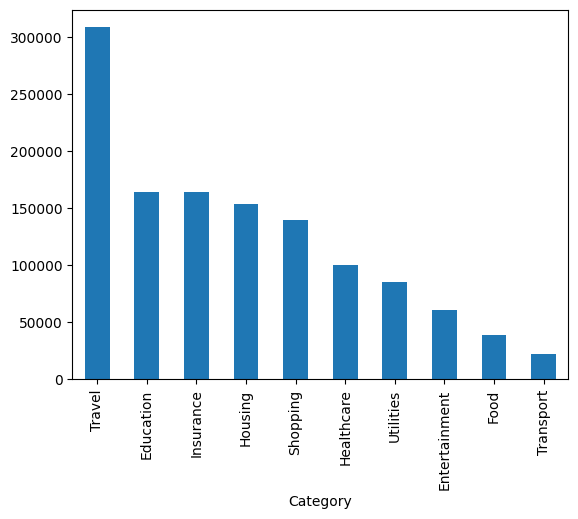

In [ ]:
category_expense.plot(kind='bar')

<Axes: ylabel='count'>

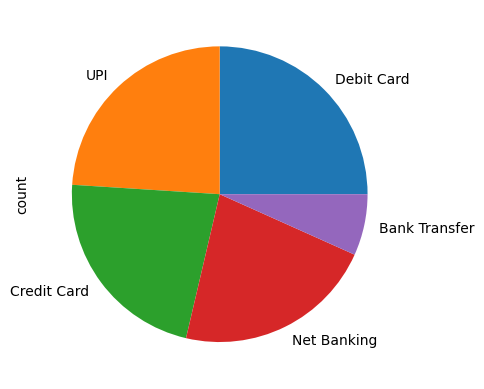

In [ ]:
df['Payment_Method'].value_counts().plot(kind='pie')

<Axes: xlabel='Merchant'>

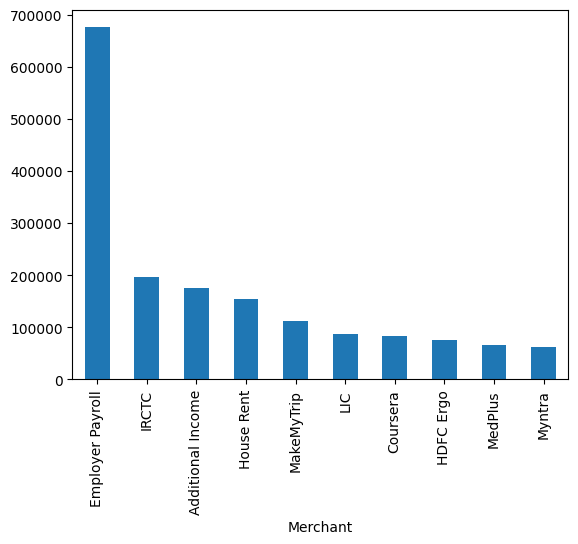

In [ ]:
top_merchants.plot(kind='bar')

<Axes: xlabel='Month'>

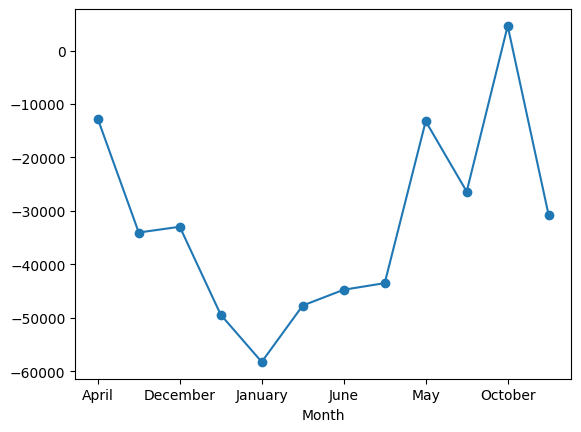

In [ ]:
#Which months had the highest and lowest savings?
income = (
    df[df['Type']=='Income']
    .groupby('Month')['Amount']
    .sum()
)

expense = (
    df[df['Type']=='Expense']
    .groupby('Month')['Amount']
    .sum()
)

savings = income - expense

savings.plot(kind='line', marker='o')

<Axes: xlabel='Category'>

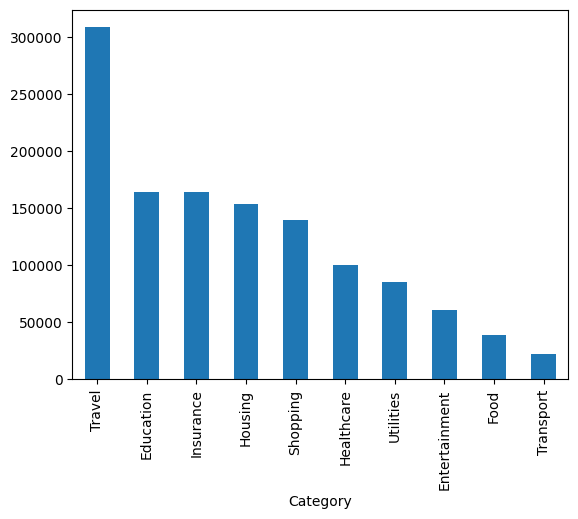

In [ ]:
#Top 10 Expense Categories
top_categories = (
    df[df['Type']=='Expense']
    .groupby('Category')['Amount']
    .sum()
    .sort_values(ascending=False)
)

top_categories.plot(kind='bar')

<Axes: ylabel='Amount'>

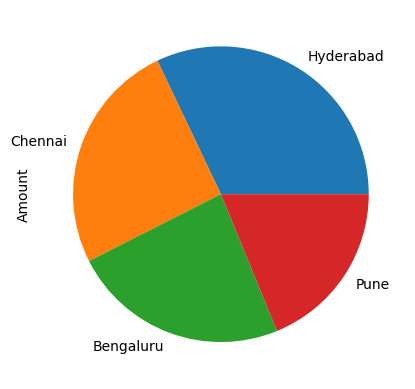

In [ ]:
city_spending = (
    df[df['Type']=='Expense']
    .groupby('City')['Amount']
    .sum()
    .sort_values(ascending=False)
)

city_spending.plot(kind='pie')

#Which city generated the highest spending?

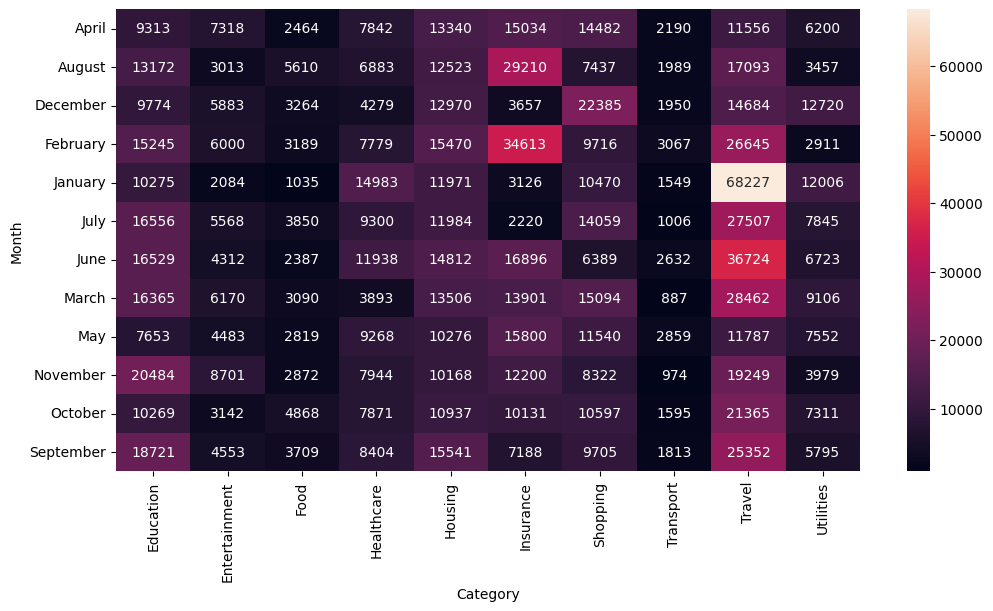

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

pivot = pd.pivot_table(
    df[df['Type']=='Expense'],
    values='Amount',
    index='Month',
    columns='Category',
    aggfunc='sum'
)

plt.figure(figsize=(12,6))
sns.heatmap(pivot, annot=True, fmt='.0f')
plt.show()

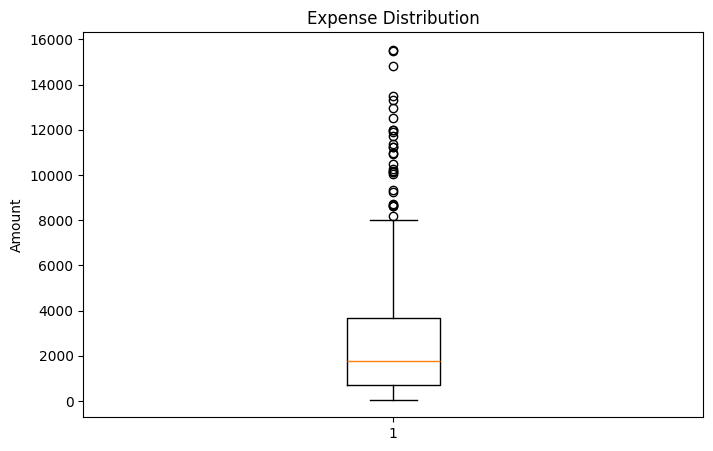

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.boxplot(df[df['Type']=='Expense']['Amount'])

plt.title("Expense Distribution")
plt.ylabel("Amount")
plt.show()

In [ ]:
!pip install squarify

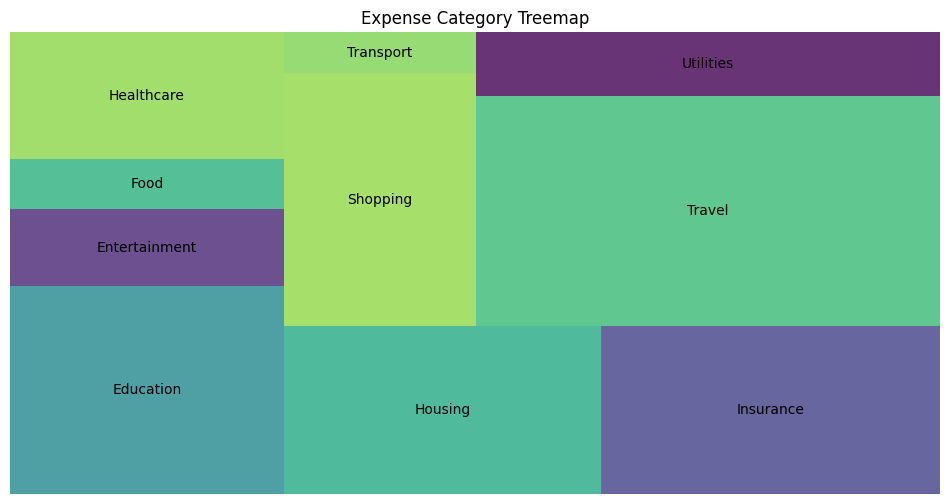

In [ ]:
import squarify
import matplotlib.pyplot as plt

category_expense = (
    df[df['Type']=='Expense']
    .groupby('Category')['Amount']
    .sum()
)

plt.figure(figsize=(12,6))

squarify.plot(
    sizes=category_expense.values,
    label=category_expense.index,
    alpha=0.8
)

plt.axis('off')
plt.title("Expense Category Treemap")
plt.show()

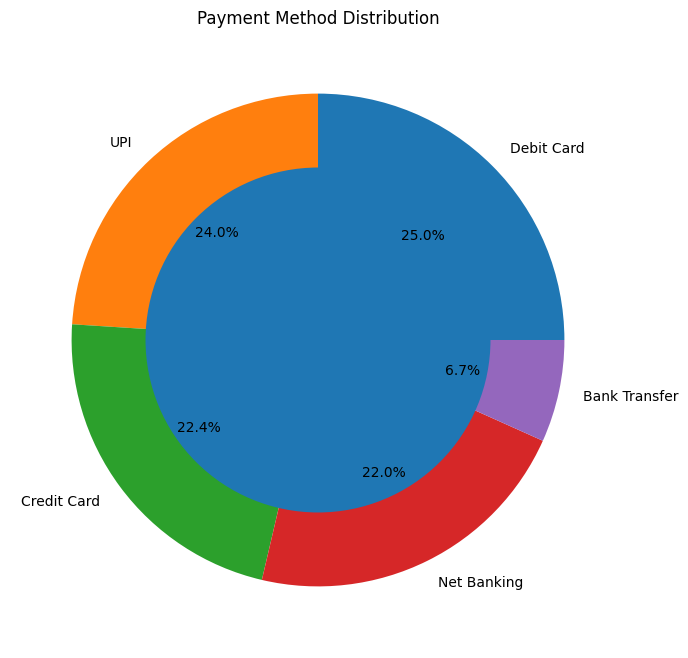

In [ ]:
payment_counts = df['Payment_Method'].value_counts()

plt.figure(figsize=(8,8))

plt.pie(
    payment_counts,
    labels=payment_counts.index,
    autopct='%1.1f%%'
)

centre_circle = plt.Circle((0,0),0.70)

fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.title("Payment Method Distribution")

plt.show()

In [ ]:
!pip install plotly

In [ ]:
import plotly.graph_objects as go

fig = go.Figure(data=[go.Sankey(
    node=dict(
        label=["Income","Food","Shopping","Travel","Rent","Savings"]
    ),
    link=dict(
        source=[0,0,0,0,0],
        target=[1,2,3,4,5],
        value=[20,25,15,25,15]
    )
)])

fig.show()


In [ ]:
from sklearn.linear_model import LinearRegression